In [32]:
%pip install transformers
%pip install spacy
%pip install emot
%pip install nltk
%pip install contractions
%pip install wordsegment

%pip install transformers accelerate torch

%pip install nlpaug
%pip install deep-translator

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import nltk
import zipfile
import copy
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from collections import Counter
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import csv

nltk.data.path.append('/kaggle/working/nltk_data')
 
nltk.download('wordnet', download_dir='/kaggle/working/nltk_data')

nltk.download('omw-1.4', download_dir='/kaggle/working/nltk_data')

nltk.download('punkt', download_dir='/kaggle/working/nltk_data')

nltk.download('averaged_perceptron_tagger', download_dir='/kaggle/working/nltk_data')
 
nltk_path = '/kaggle/working/nltk_data/corpora/'
 
with zipfile.ZipFile(nltk_path + 'wordnet.zip', 'r') as zip_ref:
    zip_ref.extractall(nltk_path)
 
with zipfile.ZipFile(nltk_path + 'omw-1.4.zip', 'r') as zip_ref:
    zip_ref.extractall(nltk_path)
 
nltk.data.path = ['/kaggle/working/nltk_data']

[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /kaggle/working/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from torch.utils.data import Dataset
from tqdm import tqdm
from sklearn.metrics import f1_score
from transformers import get_scheduler
from torch.optim import AdamW
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from emot import UNICODE_EMOJI, EMOTICONS_EMO
from nltk.tokenize import word_tokenize
from transformers import logging
from bs4 import BeautifulSoup

import torch
import re
import nltk
import spacy
import contractions
import json
import copy
import matplotlib.pyplot as plt
import wordsegment as ws
import nlpaug.augmenter.word as naw

from deep_translator import GoogleTranslator
import random
from collections import Counter

ws.load()

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4') 

model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

logging.set_verbosity_error() 

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
ner_model = spacy.load("en_core_web_sm")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


/usr/local/lib/python3.10/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


## Funzioni utili per il corretto funzionamento del programma
Useful functions for the correct functioning of the program

In [ ]:
chat_words = {
    "?4U": "I have a question for you",
    "^^": "Read line above",
    "121": "one-to-one",
    "<3": "love",
    "2": "to",
    "2mrw": "tomorrow",
    "4": "for",
    "afk": "away from keyboard",
    "aka": "also known as",
    "asaè": "as soon as possible",
    "a/s/l": "age/sex/location",
    "ayt": "Are you there?",
    "b2w": "back to work",
    "b4": "before",
    "bbl": "Be back later",
    "bbs": "Be back soon",
    "bf": "boyfriend",
    "bff": "best friend forever",
    "brb": "Be right back",
    "btw": "by the way",
    "cmb": "Call me back",
    "cmiiw": "Correct me if I'm wrong",
    "cu": "See you",
    "cu l8r": "See you later",
    "cuz": "because",
    "cos": "because",
    "cmyl": "Chat with you later",
    "dc": "disconnected",
    "diy": "Do it yourself",
    "dm": "Direct Message",
    "f2f": "face-to-face",
    "faq": "frequently asked questions",
    "fb": "Facebook",
    "fyi": "for your information",
    "fyeo": "for your eyes only",
    "gb": "goodbye",
    "gf": "girlfriend",
    "gg": "Gotta go",
    "gl": "good luck",
    "gr8": "great!",
    "hbd": "Happy Birthday",
    "hhhhhh": "very funny",
    "how r u": "How are you?",
    "ic": "I see",
    "idk": "I don't know",
    "imho": "in my humble opinion",
    "ik": "I know",
    "im": "Instant Message",
    "iow": "in other words",
    "j/k": "just kidding",
    "k": "OK",
    "l8r": "goodbye",
    "lol": "laugh out loud",
    "m/f": "male or female?",
    "mins": "minutes",
    "msg": "message",
    "nv": "nevermind",
    "oic": "Oh, I see",
    "otw": "on the way",
    "p2p": "person-to-person",
    "plz": "please",
    "pm": "Private Message",
    "rofl": "rolling on the floor laughing",
    "ruok": "Are you okay?",
    "syl": "See you later",
    "tgif": "Thank goodness it's Friday",
    "thx or thnx": "thanks",
    "ttfn": "ta ta for now",
    "ttyl": "Talk to you later",
    "tyt": "Take your time",
    "u": "you",
    "u2": "you too",
    "ur": "your",
    "w/": "with",
    "w/o": "without",
    "wru": "Where are you?",
    "xo": "love",
    "zzz": "tired"
}

def replace_emoji_with_description(text):
    for emoji, description in UNICODE_EMOJI.items():
        description = description.replace('_', ' ')
        description = description.replace(':', ' ')
        text = text.replace(emoji, description)

    for emoticon, description in EMOTICONS_EMO.items():
        description = description.replace('_', ' ')
        description = description.replace(':', ' ')
        text = text.replace(emoticon, f" {description} ")
    return text

def hashtag_divide(sentence):  
    hashtag = " ".join(ws.segment(sentence))
    return hashtag

def plot_learning_curves(history, title="Learning Curves"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.ylim(0, max(max(history['train_loss']), max(history['val_loss'])) * 1.1)
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.ylim(0, max(max(history['train_accuracy']), max(history['val_accuracy'])) * 1.1)
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['f1_macro'], label='F1-macro')
    plt.plot(epochs, history['f1_weighted'], label='F1-weighted')
    plt.xlabel('Epochs')
    plt.ylabel('F1')
    plt.title('F1 Curve')
    plt.ylim(0, max(max(history['f1_macro']), max(history['f1_weighted'])) * 1.1)
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def conf_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predetto")
    plt.ylabel("Vero")
    plt.title("Matrice di Confusione")

    plt.show()
    
def save_test(test_dataloader, model, device, j, epoch):
    predict = []
    output_csv_path = f"test_tweet_label{j}_epoch{epoch}.csv"
    model.eval()

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)

            predict.extend(predictions.cpu().numpy())

    with open(output_csv_path, mode="w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["label"])
        for y in predict:
            writer.writerow([f"{y}"])

    return predict

## Implementazione EarlyStopping
EarlyStopping implementation

In [ ]:
class EarlyStopping:
    def __init__(self, patience = 3, min_delta = 0.0):

        self.best_model = None
        self.patience = patience
        self.min_delta = min_delta
        
        self.counter = 0
        self.early_stop = False
        self.max_accuracy = 0

    def __call__(self, val_accuracy, model):

        if (self.max_accuracy - val_accuracy) >= self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print("Early stop!")
        else:
            if val_accuracy >= self.max_accuracy: 
                self.max_accuracy = val_accuracy
                self.best_model = copy.deepcopy(model)                                            
            self.counter = 0

In [37]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length, preprocessing):             
        cleaned_texts = texts.copy()

        if preprocessing["hashtag"]:
            cleaned_texts = [' '.join([hashtag_divide(word) if word[0] == "#" else word for word in sentence.split()]) for sentence in cleaned_texts]

        if preprocessing["chatwords"]:
            cleaned_texts = [' '.join([chat_words[word] if word in chat_words else word for word in sentence.split()]) for sentence in cleaned_texts]
        
        if preprocessing['remove_slash_n']:
            cleaned_texts = [re.sub(r"\\n", " ", sentence) for sentence in cleaned_texts]

        if preprocessing["remove_link"]:
            cleaned_texts = [re.sub(r'http\S+|www.\S+', '', sentence) for sentence in cleaned_texts]

        if preprocessing['change_emoticon']:
            cleaned_texts = [replace_emoji_with_description(text) for text in cleaned_texts]

        if preprocessing['remove_tag']:
            cleaned_texts = [re.sub(r"@\w+", "", sentence) for sentence in cleaned_texts]

        if preprocessing['remove_number']:
            cleaned_texts = [re.sub(r"\s([0-9]+[:|.]*[0-9]*)\s", "", sentence) for sentence in cleaned_texts]
        
        if preprocessing['expand_contractions']:
            cleaned_texts = [contractions.fix(sentence) for sentence in cleaned_texts]
        
        if preprocessing['apply_pos']:
            text = []
            for sentence in cleaned_texts:
                pos_sentence = ' '.join([word for word, tag in nltk.pos_tag(nltk.word_tokenize(sentence)) if tag not in ['PRP', 'PRP$', 'DT', 'IN']])
                pos_sentence = pos_sentence.replace(" ", "")
                cleaned_sentence = ' '.join([word for word in sentence.split() if word in pos_sentence or word == " "])
                text.append(cleaned_sentence)
            cleaned_texts = text

        if preprocessing['apply_ner']:
            text = []
            for sentence in cleaned_texts:
                ner_sentence = ' '.join([token.text for token in ner_model(sentence) if token.ent_type_ not in ['PERSON', 'GPE', 'TIME', 'DATE', 'MONEY', 'LOC']])
                ner_sentence = ner_sentence.replace(" ", "")
                cleaned_sentence = ' '.join([word for word in sentence.split() if word in ner_sentence or word == " "])
                text.append(cleaned_sentence)
            cleaned_texts = text

        if preprocessing['apply_lemmatization']:
            cleaned_texts = [" ".join([token.lemma_.upper() if token.text.isupper() else token.lemma_ for token in ner_model(text)]) for text in cleaned_texts]

        if preprocessing['apply_stemming']:
            cleaned_texts = [' '.join([stemmer.stem(word) for word in nltk.word_tokenize(sentence)]) for sentence in cleaned_texts]
                 
        self.texts = [re.sub(r"\s+", " ", sentence).strip() for sentence in cleaned_texts]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texttext = self.texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        if self.labels is not None:
            label = self.labels[idx]
            return {
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0),
                "labels": torch.tensor(label, dtype=torch.long)
            }
        else:
            return {
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0)
            }

In [ ]:
j = 0
def train(train_dataloader, val_dataloader, test_dataloader, model, device, config):

    global j
    j += 1
    
    warmup_steps = config['warmup_steps']
    lr = config['lr']
    num_epochs = config['epochs']
    scheduler = config['scheduler']
    
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "f1_macro": [],
        "f1_weighted": []
    }
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    num_training_steps = len(train_dataloader) * num_epochs
    lr_scheduler = get_scheduler(scheduler, optimizer=optimizer, num_warmup_steps=warmup_steps*num_training_steps, num_training_steps=num_training_steps)
    early_stopping = EarlyStopping(patience=3, min_delta=0)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs} - Training"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            train_loss += loss.item()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

            probabilities = torch.softmax(outputs.logits, dim=-1)
            predictions = torch.argmax(probabilities, dim=-1)   
            
            correct += (predictions == batch["labels"]).sum().item()
            total += batch["labels"].size(0)

        train_loss /= len(train_dataloader)
        train_accuracy = correct / total
        
        val_loss, val_accuracy, f1_macro, f1_weighted = validation(val_dataloader, model, device) # type: ignore
        print(f"Epoch {epoch + 1}, Training Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
        
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['f1_macro'].append(f1_macro)
        history['f1_weighted'].append(f1_weighted)
        
        early_stopping(val_accuracy, model)
        if early_stopping.early_stop:
            print("Early stopping attivato!")
            break

        save_test(test_dataloader, model, device, j, epoch+1)

    return early_stopping.best_model, history
    

In [39]:
def validation(val_dataloader, model, device, label=False):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            
            val_loss += loss.item()
            
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == batch["labels"]).sum().item()
            total += batch["labels"].size(0)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Waited): {f1_weighted:.4f}")
    
    val_loss /= len(val_dataloader)
    accuracy = correct / total
    
    if label:
        return all_predictions, f1_macro, f1_weighted
    
    return val_loss, accuracy, f1_macro, f1_weighted


In [ ]:

def dataAugmentationCopy(train_x, train_y, target_size=1400):
    dic = Counter(train_y)
    
    label_dict = {label: [] for label in dic.keys()}
    for text, label in zip(train_x, train_y):
        label_dict[label].append(text)

    new_train_x = []
    new_train_y = []

    for label, texts in label_dict.items():
        current_size = len(texts)
        if current_size < target_size:
            multiplier = target_size // current_size
            remainder = target_size % current_size
            
            augmented_texts = texts * multiplier  
            
            augmented_texts += random.choices(texts, k=remainder)

            new_train_x.extend(augmented_texts)
            new_train_y.extend([label] * target_size)
        else:
            new_train_x.extend(texts[:-1])
            new_train_y.extend([label] * current_size)

    return new_train_x, new_train_y

def dataAugmentationNlpAug(train_x, train_y, min_samples_per_class=1400):
    class_counts = Counter(train_y)
    
    synonym_aug = naw.SynonymAug(aug_src='wordnet') 
    insert_aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert") 
    delete_aug = naw.RandomWordAug(action="delete")

    new_train_x = list(train_x)
    new_train_y = list(train_y)

    for label, count in class_counts.items():
        if count < min_samples_per_class:
            samples_needed = min_samples_per_class - count
            
            original_texts = [text for text, lbl in zip(train_x, train_y) if lbl == label]
            
            for _ in range(samples_needed):
                original_text = random.choice(original_texts)
                
                augment_choice = random.choice(["synonym", "insert", "delete"])
                if augment_choice == "synonym":
                    new_text = synonym_aug.augment(original_text)
                elif augment_choice == "insert":
                    new_text = insert_aug.augment(original_text)    

                elif augment_choice == "delete":
                    new_text = delete_aug.augment(original_text)

                if isinstance(new_text, list):
                    new_text = " ".join(new_text)

                new_train_x.append(new_text)
                new_train_y.append(label)

    return new_train_x, new_train_y

def dataAugmentationTranslate(train_x, train_y, min_samples_per_class=1400):
    translator = GoogleTranslator()

    class_counts = Counter(train_y)

    new_train_x = list(train_x)
    new_train_y = list(train_y)

    for label, count in class_counts.items():
        if count < min_samples_per_class:
            samples_needed = min_samples_per_class - count
            
            original_texts = [text for text, lbl in zip(train_x, train_y) if lbl == label]
            
            for _ in range(samples_needed):
                original_text = random.choice(original_texts)
                
                translated = translator.translate(original_text, source='en', target='fr')
                new_text = translator.translate(translated, source='fr', target='en')

                new_train_x.append(new_text)
                new_train_y.append(label)
    
    return new_train_x, new_train_y


def lemmatize_text_spacy_preserve_case(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    lemmatized_tokens = []

    for token in doc:
        lemma = token.lemma_
        if token.text.isupper():
            lemma = lemma.upper()
        elif token.text.istitle():
            lemma = lemma.capitalize()
        lemmatized_tokens.append(lemma)

    return " ".join(lemmatized_tokens)

def replace_chat_words(sentence, chat_words_dict):
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in chat_words_dict.keys()) + r')\b', re.IGNORECASE)
    
    def replace(match):
        word = match.group(0).lower()
        return chat_words_dict.get(word, word)
    return pattern.sub(replace, sentence)

def expand_contractions_in_text(text):
    return contractions.fix(text)

def dataAugmentationLemming(train_x, train_y, chat_words_dict, min_samples_per_class=1400):
    class_counts = Counter(train_y)

    new_train_x = list(train_x)
    new_train_y = list(train_y)
    
    modified_texts = []

    for label, count in class_counts.items():
        if count < min_samples_per_class:
            samples_needed = min_samples_per_class - count
            
            original_texts = [text for text, lbl in zip(train_x, train_y) if lbl == label]
            
            for _ in range(samples_needed):
                original_text = random.choice(original_texts)
                
                modified_text = replace_chat_words(original_text, chat_words_dict)
                modified_text = expand_contractions_in_text(modified_text)
                modified_text = replace_emoji_with_description(modified_text)
                new_text = lemmatize_text_spacy_preserve_case(modified_text)

                if new_text != original_text:
                    modified_texts.append((new_text, label))
    
    new_train_x.extend([text for text, _ in modified_texts])
    new_train_y.extend([label for _, label in modified_texts])

    remaining_samples_needed = min_samples_per_class - len(modified_texts)
    if remaining_samples_needed > 0:
        for _ in range(remaining_samples_needed):
            new_train_x.append(random.choice(new_train_x))
            new_train_y.append(label)

    return new_train_x, new_train_y, modified_texts

In [ ]:
def import_data(preprocessing,config):
    
    train_x_path = "./datasets/emotion/train_text.txt"
    train_y_path = "./datasets/emotion/train_labels.txt"
    val_x_path = "./datasets/emotion/val_text.txt"
    val_y_path = "./datasets/emotion/val_labels.txt"
    test_x_path = "./datasets/emotion/test_text.txt"

    with open(train_x_path, "r", encoding="utf-8") as f:
        train_x = [line.strip() for line in f]

    with open(train_y_path, "r", encoding="utf-8") as f:
        train_y = [int(line.strip()) for line in f]

    with open(val_x_path, "r", encoding="utf-8") as f:
        val_x = [line.strip() for line in f]

    with open(val_y_path, "r", encoding="utf-8") as f:
        val_y = [int(line.strip()) for line in f]

    with open(test_x_path, "r", encoding="utf-8") as f:
        test_x = [line.strip() for line in f]

    train_x, train_y = dataAugmentationCopy(train_x, train_y, 1400)

    train_dataset = EmotionDataset(train_x, train_y, tokenizer, max_length=128, preprocessing = preprocessing)
    val_dataset = EmotionDataset(val_x, val_y, tokenizer, max_length=128, preprocessing = preprocessing)
    test_dataset = EmotionDataset(test_x, None, tokenizer, max_length=128, preprocessing = preprocessing)

    train_dataloader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=config['batch_size'])
    test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'])

    return train_dataloader, val_dataloader, test_dataloader, val_y

In [43]:
def main_with_train(preprocessing, config):
    
    train_dataloader, val_dataloader, test_dataloader, val_y = import_data(preprocessing, config)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 4, hidden_dropout_prob = config['dropout_rate'])
    torch.cuda.empty_cache()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_model, history = train(train_dataloader, val_dataloader, test_dataloader, model, device, config)
    plot_learning_curves(history)

    val_pred, f1_macro,f1_weighted = validation(val_dataloader, best_model, device, label=True)
    conf_matrix(val_y, val_pred)

    global j
    save_test(test_dataloader, best_model, device, j, "last")

    name = "_".join([f"{key}_{str(value)}" for key, value in config.items()])
    name += f"_f1Macro_{f1_macro:.4f}_f1Weighted_{f1_weighted:.4f}"
    
    path = f"./emotion_model_{name}"
    best_model.save_pretrained(path)
    with open(f"{path}/preprocessing_selected.json", 'w') as f:
        json.dump(preprocessing, f, indent=4)

In [ ]:
from sklearn.model_selection import ParameterGrid

preprocessing = {
    "hashtag" : False,
    "chatwords": True,
    "remove_slash_n": False,
    "remove_link": False,
    "change_emoticon":True,
    "remove_tag":False,
    "expand_contractions":True,
    "apply_pos":False,
    "apply_ner":False,
    "apply_lemmatization":False,
    "apply_stemming":False,
    "remove_number":False
}

# Best Iperparameter
param_grid = {
    'lr': [1e-5],
    'epochs': [20],
    'batch_size':[16],
    'dropout_rate': [0.2],
    'warmup_steps': [0.1],
    'scheduler': ["cosine"]
}

grid = ParameterGrid(param_grid)

1
['chatwords', 'change_emoticon', 'expand_contractions']
Testing combination: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 20, 'lr': 1e-05, 'scheduler': 'cosine', 'warmup_steps': 0.1}


Epoch 1/20 - Training: 100%|██████████| 350/350 [01:33<00:00,  3.72it/s]


F1 Score (Macro): 0.3425
F1 Score (Waited): 0.3018
Epoch 1, Training Loss: 1.3831, Train Accuracy: 0.2745, Validation Loss: 1.3136, Validation Accuracy: 0.3877


Epoch 2/20 - Training: 100%|██████████| 350/350 [01:33<00:00,  3.73it/s]


F1 Score (Macro): 0.7546
F1 Score (Waited): 0.8059
Epoch 2, Training Loss: 0.8799, Train Accuracy: 0.6448, Validation Loss: 0.5738, Validation Accuracy: 0.8021


...

F1 Score (Macro): 0.7904
F1 Score (Waited): 0.8448
Epoch 6, Training Loss: 0.1275, Train Accuracy: 0.9620, Validation Loss: 0.7371, Validation Accuracy: 0.8396


Epoch 7/20 - Training: 100%|██████████| 350/350 [01:33<00:00,  3.73it/s]


F1 Score (Macro): 0.7484
F1 Score (Waited): 0.8105
Epoch 7, Training Loss: 0.1013, Train Accuracy: 0.9693, Validation Loss: 0.8993, Validation Accuracy: 0.8075


Epoch 8/20 - Training: 100%|██████████| 350/350 [01:33<00:00,  3.73it/s]


F1 Score (Macro): 0.7458
F1 Score (Waited): 0.8088
Epoch 8, Training Loss: 0.0793, Train Accuracy: 0.9741, Validation Loss: 0.8974, Validation Accuracy: 0.8102
Early stop!
Early stopping attivato!


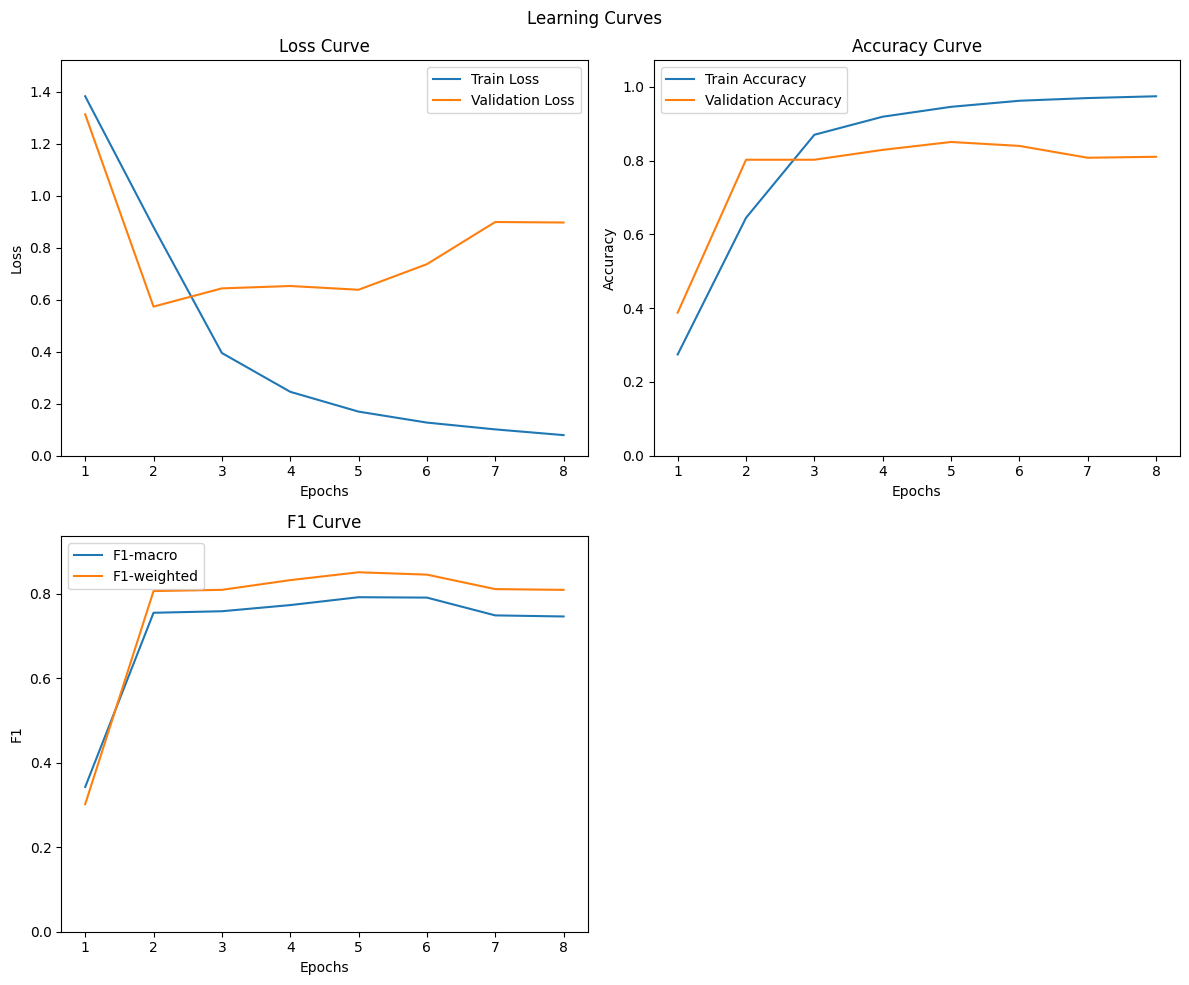

F1 Score (Macro): 0.7914
F1 Score (Waited): 0.8504


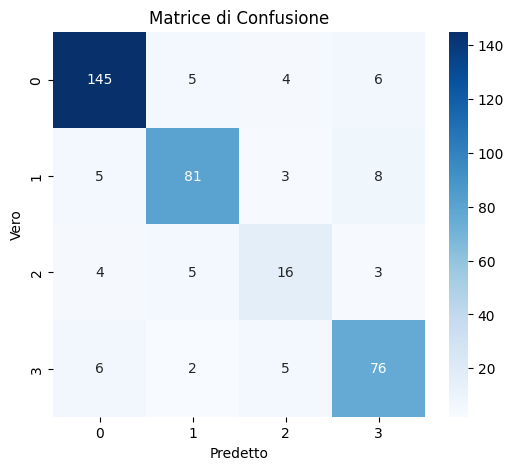

In [46]:
true_keys = [key for key, value in preprocessing.items() if value]
k = 1
for params in grid:
    print(k)
    print(true_keys)
    print(f"Testing combination: {params}")
    main_with_train(preprocessing, params)
    k = k + 1

In [ ]:
import pandas as pd
import os

def aggregate_predictions(folder_path):
    file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]
    
    dataframes = [pd.read_csv(file) for file in file_paths]
    combined_df = pd.concat(dataframes, axis=1, keys=[f"model_{i}" for i in range(len(dataframes))])
    
    final_labels = []
    for _, row in combined_df.iterrows():
        labels = [row[f'model_{i}']['label'] for i in range(len(dataframes))]
        most_probable_label = pd.Series(labels).mode()[0]
        final_labels.append(most_probable_label)
    
    result_df = pd.DataFrame(final_labels, columns=["label"])
    
    return result_df

folder_path = ".\model_predictions"

result_df = aggregate_predictions(folder_path)
result_df.to_csv('aggregated_predictions.csv', index=False)